# Raw Data Inspection
Exploratory inspection of all raw datasets for the EAFM-PolyGet MLFF project.

## Dataset overview

| # | Dataset | Tier | Theory | Quality | Raw frames | Elements |
|---|---------|------|--------|---------|-----------|----------|
| 1 | **AIMNet2** | T1 | wB97M-D3(BJ)/def2-TZVPP | Excellent | 5.8 M | CHONF·Si·P·S·Cl·Br |
| 2 | **SPICE-2** | T1 | wB97M-D3(BJ)/def2-TZVPPD | Excellent | 2.0 M | CHONF·Si·P·S·Cl·Br + ionic |
| 3 | **QDpi** | T1 | wB97M-D3(BJ)/def2-TZVPPD | Excellent | 540 k | CHONF·S·Cl |
| 4 | **SPF** | T2 | revPBE-D3(BJ)/def2-TZVP | Good | 2.7 M | HCNOS |
| 5 | **ANI-2x** | T2 | wB97X/6-31G* | Good | 9.7 M | HCNOF·S·Cl |

Preprocessing filters applied uniformly (except where noted):
- **Element filter**: keep {H, C, N, O, F, Si, P, S, Cl, Br}
- **Charge filter**: keep neutral molecules only (Q = 0)
- **Energy filter**: keep −1000 ≤ E/atom ≤ −0.4 Ha (total DFT datasets); eV-scale check for SPF
- **Force filter**: drop conformers with any |F| > 20 eV/Å


In [1]:
import h5py
import numpy as np
from collections import defaultdict
from pathlib import Path

RAW = Path("raw")

ATOMIC_SYMBOLS = {
    1: "H", 5: "B", 6: "C", 7: "N", 8: "O", 9: "F",
    14: "Si", 15: "P", 16: "S", 17: "Cl",
    33: "As", 34: "Se", 35: "Br", 53: "I",
}

# Element set kept after preprocessing
ALLOWED_Z = frozenset([1, 6, 7, 8, 9, 14, 15, 16, 17, 35])
#                      H  C  N  O  F  Si   P   S  Cl  Br

---
## AIMNet2 — Tier 1 · wB97M-D3(BJ)/def2-TZVPP · Excellent

**Structure:** HDF5 groups keyed by atom count (`'002'`–`'076'`).  
Each group contains:

| Dataset | Shape | Dtype | Unit |
|---------|-------|-------|------|
| `coord` | (N, n_atoms, 3) | float32 | Å |
| `forces` | (N, n_atoms, 3) | float32 | eV/Å |
| `energy` | (N,) | float64 | Hartree |
| `numbers` | (N, n_atoms) | int8 | atomic number |
| `charge` | (N,) | int8 | total molecular charge |
| `charges` | (N, n_atoms) | float32 | per-atom partial charge |
| `dipole` | (N, 3) | float32 | — |
| `quadrupole` | (N, 6) | float32 | — |

In [2]:
with h5py.File(RAW / "aimnet2/aimnet2_wb97m.h5", "r") as f:
    groups = sorted(f.keys())
    print(f"Groups (atom counts): {groups[0]} – {groups[-1]}  ({len(groups)} total)")
    print(f"\nDatasets in group '{groups[5]}':")
    for k, v in f[groups[5]].items():
        print(f"  {k:12s}  shape={v.shape}  dtype={v.dtype}")

Groups (atom counts): 002 – 076  (75 total)

Datasets in group '007':
  charge        shape=(186042,)  dtype=int8
  charges       shape=(186042, 7)  dtype=float32
  coord         shape=(186042, 7, 3)  dtype=float32
  dipole        shape=(186042, 3)  dtype=float32
  energy        shape=(186042,)  dtype=float64
  forces        shape=(186042, 7, 3)  dtype=float32
  numbers       shape=(186042, 7)  dtype=int8
  quadrupole    shape=(186042, 6)  dtype=float32


### 1. Raw dataset overview

In [3]:
total_conf = 0
size_counts = {}
element_counts = defaultdict(int)
charge_counts = defaultdict(int)
energies = []

with h5py.File(RAW / "aimnet2/aimnet2_wb97m.h5", "r") as f:
    for g in sorted(f.keys()):
        grp = f[g]
        n = grp["energy"].shape[0]
        total_conf += n
        size_counts[int(g)] = n
        for z, cnt in zip(*np.unique(grp["numbers"][:], return_counts=True)):
            element_counts[int(z)] += int(cnt)
        for c in grp["charge"][:]:
            charge_counts[int(c)] += 1
        energies.append(grp["energy"][:])

energies = np.concatenate(energies)
print(f"Total conformers : {total_conf:,}")
print(f"Atom-count range : {min(size_counts)} – {max(size_counts)}")
print(f"\nElement distribution (total atoms across all conformers):")
for z, cnt in sorted(element_counts.items()):
    sym = ATOMIC_SYMBOLS.get(z, f"Z{z}")
    keep_str = "KEEP" if z in ALLOWED_Z else "DROP"
    print(f"  {sym:>4} (Z={z:2d})  {cnt:>15,}  [{keep_str}]")

Total conformers : 20,108,565
Atom-count range : 2 – 76

Element distribution (total atoms across all conformers):
     H (Z= 1)      215,241,457  [KEEP]
     B (Z= 5)          471,871  [DROP]
     C (Z= 6)      149,946,572  [KEEP]
     N (Z= 7)       45,708,663  [KEEP]
     O (Z= 8)       35,810,619  [KEEP]
     F (Z= 9)        4,988,458  [KEEP]
    Si (Z=14)        1,154,816  [KEEP]
     P (Z=15)        3,277,820  [KEEP]
     S (Z=16)       10,284,295  [KEEP]
    Cl (Z=17)        4,256,399  [KEEP]
    As (Z=33)           69,671  [DROP]
    Se (Z=34)          237,561  [DROP]
    Br (Z=35)        1,855,752  [KEEP]
     I (Z=53)        1,320,063  [DROP]


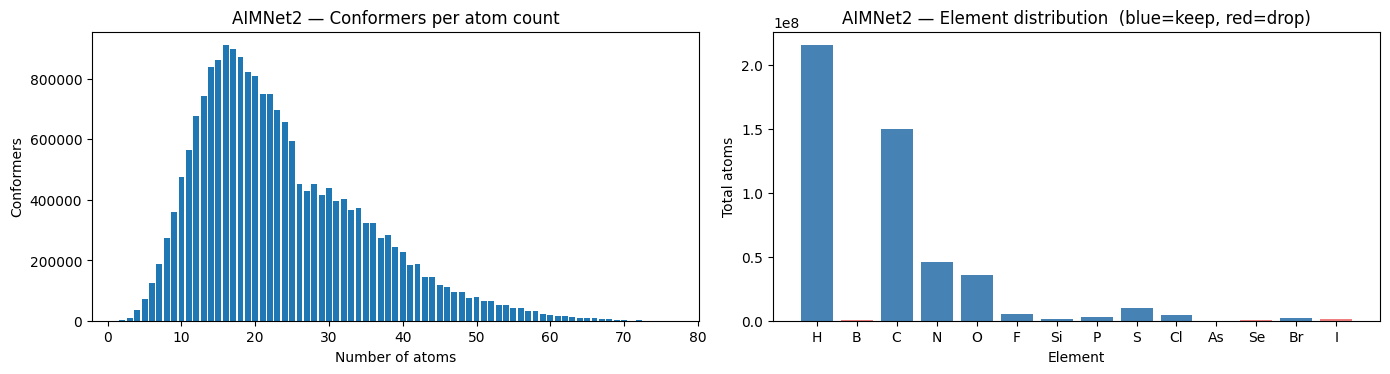

In [4]:
import matplotlib.pyplot as plt

sizes  = sorted(size_counts.keys())
counts = [size_counts[s] for s in sizes]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(sizes, counts, width=0.8)
axes[0].set_xlabel("Number of atoms")
axes[0].set_ylabel("Conformers")
axes[0].set_title("AIMNet2 — Conformers per atom count")

syms    = [ATOMIC_SYMBOLS.get(z, f"Z{z}") for z in sorted(element_counts)]
ecounts = [element_counts[z] for z in sorted(element_counts)]
colors  = ["steelblue" if z in ALLOWED_Z else "lightcoral" for z in sorted(element_counts)]
axes[1].bar(syms, ecounts, color=colors)
axes[1].set_xlabel("Element")
axes[1].set_ylabel("Total atoms")
axes[1].set_title("AIMNet2 — Element distribution  (blue=keep, red=drop)")

plt.tight_layout()
plt.show()

In [5]:
print("Molecular charge distribution:")
for c, n in sorted(charge_counts.items()):
    keep_str = "keep" if c == 0 else "drop"
    print(f"  {c:+3d} : {n:>10,}  [{keep_str}]")

print(f"\nEnergy (Ha)  min={energies.min():.4f}  max={energies.max():.4f}  "
      f"mean={energies.mean():.4f}  std={energies.std():.4f}")

Molecular charge distribution:
   -8 :        168  [drop]
   -7 :        565  [drop]
   -6 :      4,490  [drop]
   -5 :     13,486  [drop]
   -4 :     65,374  [drop]
   -3 :    174,089  [drop]
   -2 :    846,841  [drop]
   -1 :  3,580,002  [drop]
   +0 : 10,230,127  [keep]
   +1 :  3,737,784  [drop]
   +2 :  1,129,289  [drop]
   +3 :    242,165  [drop]
   +4 :     68,381  [drop]
   +5 :     11,598  [drop]
   +6 :      3,474  [drop]
   +7 :        641  [drop]
   +8 :         87  [drop]
   +9 :          4  [drop]

Energy (Ha)  min=-962370.7318  max=-31.5997  mean=-33772.2315  std=35144.3956


### 2. Data quality checks

In [6]:
# NaN / Inf scan (full dataset)
print("NaN / Inf scan:")
n_issues = 0
with h5py.File(RAW / "aimnet2/aimnet2_wb97m.h5", "r") as f:
    for g in sorted(f.keys()):
        for key in ["energy", "forces", "coord"]:
            d = f[g][key][:]
            if np.isnan(d).any() or np.isinf(d).any():
                print(f"  PROBLEM  group {g} / {key}: NaN={np.isnan(d).sum()}  Inf={np.isinf(d).sum()}")
                n_issues += 1
if n_issues == 0:
    print("  Clean — no NaN or Inf found in any group.")

NaN / Inf scan:
  Clean — no NaN or Inf found in any group.


In [7]:
# Force conservation: sum of forces per conformer should ≈ 0
with h5py.File(RAW / "aimnet2/aimnet2_wb97m.h5", "r") as f:
    forces_sample = f["010"]["forces"][:500]

fsum = forces_sample.sum(axis=1)   # (500, 3)
print("Force conservation check (group '010', 500 conformers):")
print(f"  mean |sum F| per conformer: {np.linalg.norm(fsum, axis=-1).mean():.2e} eV/Å")
print(f"  max  |sum F| per conformer: {np.linalg.norm(fsum, axis=-1).max():.2e} eV/Å")
print("  -> forces are well-conserved (F = -dE/dr convention confirmed)")

Force conservation check (group '010', 500 conformers):
  mean |sum F| per conformer: 2.18e-02 eV/Å
  max  |sum F| per conformer: 9.37e-02 eV/Å
  -> forces are well-conserved (F = -dE/dr convention confirmed)


Force magnitude distribution (eV/Å):
  p 50.0: 1.595
  p 90.0: 4.588
  p 95.0: 6.111
  p 99.0: 11.582
  p 99.9: 26.548
  p100.0: 96.724


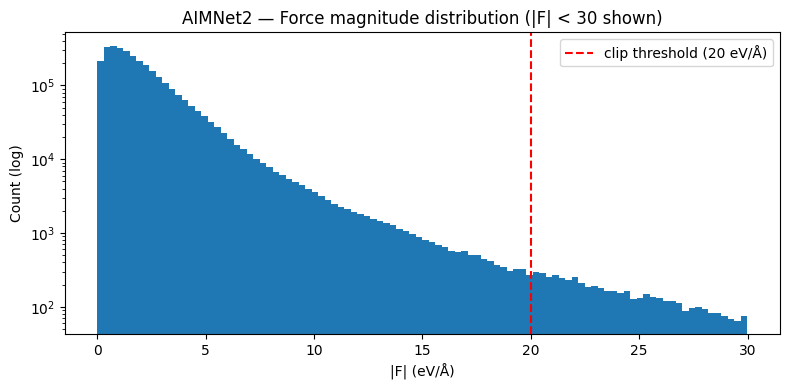

In [8]:
# Force magnitude distribution (sampled)
rng = np.random.default_rng(42)
force_mags = []
sampled = 0
BUDGET = 500_000

with h5py.File(RAW / "aimnet2/aimnet2_wb97m.h5", "r") as f:
    for g in sorted(f.keys()):
        if sampled >= BUDGET:
            break
        forces = f[g]["forces"][:]
        n = forces.shape[0]
        take = min(n, BUDGET - sampled)
        idx = rng.choice(n, take, replace=False)
        force_mags.append(np.linalg.norm(forces[idx], axis=-1).flatten())
        sampled += take

force_mags = np.concatenate(force_mags)

print("Force magnitude distribution (eV/Å):")
for p in [50, 90, 95, 99, 99.9, 100]:
    print(f"  p{p:5.1f}: {np.percentile(force_mags, p):.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(force_mags[force_mags < 30], bins=100, log=True)
ax.axvline(20, color="red", linestyle="--", label="clip threshold (20 eV/Å)")
ax.set_xlabel("|F| (eV/Å)")
ax.set_ylabel("Count (log)")
ax.set_title("AIMNet2 — Force magnitude distribution (|F| < 30 shown)")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Energy per atom — check for corrupted entries (raw dataset, no element filter)
E_MIN, E_MAX = -1000.0, -0.4   # Ha/atom
print(f"Energy outliers (e/atom < {E_MIN} or > {E_MAX} Ha):")
n_outliers = 0
with h5py.File(RAW / "aimnet2/aimnet2_wb97m.h5", "r") as f:
    for g in sorted(f.keys()):
        n_atoms = int(g)
        energy  = f[g]["energy"][:]
        numbers = f[g]["numbers"][:]
        epa     = energy / n_atoms
        bad     = np.where((epa < E_MIN) | (epa > E_MAX))[0]
        for i in bad:
            syms = [ATOMIC_SYMBOLS.get(int(z), f"Z{z}") for z in numbers[i]]
            bound = "low" if epa[i] < E_MIN else "high"
            print(f"  group {g}, conf {i}: e/atom={epa[i]:.2f} Ha  atoms={syms}  [{bound}]")
            n_outliers += 1
            if n_outliers >= 10:
                print("  ... (showing first 10 only)")
                break
        if n_outliers >= 10:
            break

if n_outliers == 0:
    print("  No outliers found.")

Energy outliers (e/atom < -1000.0 or > -0.4 Ha):
  group 002, conf 0: e/atom=-7620.27 Ha  atoms=['Cl', 'F']  [low]
  group 002, conf 1: e/atom=-7620.25 Ha  atoms=['Cl', 'F']  [low]
  group 002, conf 2: e/atom=-2045.79 Ha  atoms=['O', 'O']  [low]
  group 002, conf 3: e/atom=-10833.46 Ha  atoms=['S', 'S']  [low]
  group 002, conf 4: e/atom=-33697.73 Ha  atoms=['O', 'Se']  [low]
  group 002, conf 5: e/atom=-6441.35 Ha  atoms=['O', 'S']  [low]
  group 002, conf 6: e/atom=-1264.22 Ha  atoms=['C', 'N']  [low]
  group 002, conf 7: e/atom=-7620.26 Ha  atoms=['F', 'Cl']  [low]
  group 002, conf 8: e/atom=-10313.70 Ha  atoms=['Cl', 'I']  [low]
  group 002, conf 9: e/atom=-32683.61 Ha  atoms=['Se', 'H']  [low]
  ... (showing first 10 only)


### 3. Filter retention estimate

Preprocessing pipeline:
1. **Element filter** — keep `{H, C, N, O, F, Si, P, S, Cl, Br}`, drop `{B, As, Se, I}`
2. **Charge filter** — keep `charge == 0` (neutral only)
3. **Energy filter** — keep −1000 ≤ E/atom ≤ −0.4 Ha
4. **Force filter** — drop conformers with any |F| > 20 eV/Å

---

**Charge filter rationale — why neutral only:**

The model takes only `z` (atomic numbers) and `pos` (positions) as inputs. There is no charge input feature. This matters differently depending on the type of charged species:

- **Radical ions** (same `z` as neutral, electron added/removed): the model has zero signal to distinguish these from neutral molecules. Including them forces the model to predict forces/energies for geometries it cannot identify as charged — predictions will be systematically wrong with no architectural fix possible at training time.

- **Protonated/deprotonated species** (different `z` due to extra/missing H): the geometry *does* encode the charge state through the atomic number change, so there is no ambiguity. However, the fine-tuning target (CHONS VASP polymer AIMD) is entirely neutral — including these shifts pretraining toward ionic chemistry that will never appear downstream, spending model capacity on irrelevant regimes.

> If total charge is added as a model input feature in future, this filter should be revisited — protonated/deprotonated species would then be unambiguously beneficial to include.

In [10]:
MAX_FORCE  = 20.0
MAX_CHARGE = 0      # neutral only — see rationale above
E_MIN, E_MAX = -1000.0, -0.4   # Ha/atom

stats = defaultdict(int)

with h5py.File(RAW / "aimnet2/aimnet2_wb97m.h5", "r") as f:
    for g in sorted(f.keys()):
        grp     = f[g]
        numbers = grp["numbers"][:].astype(np.int16)
        charges = grp["charge"][:]
        energy  = grp["energy"][:]
        forces  = grp["forces"][:]
        N       = len(charges)
        n_atoms = int(g)

        stats["total"] += N

        elem_ok   = np.isin(numbers, sorted(ALLOWED_Z)).all(axis=1)
        charge_ok = charges == MAX_CHARGE
        epa       = energy / n_atoms
        energy_ok = (epa >= E_MIN) & (epa <= E_MAX)
        fmag_max  = np.linalg.norm(forces, axis=-1).max(axis=1)
        force_ok  = fmag_max <= MAX_FORCE

        stats["after_elem"]   += int((elem_ok).sum())
        stats["after_charge"] += int((elem_ok & charge_ok).sum())
        stats["after_energy"] += int((elem_ok & charge_ok & energy_ok).sum())
        stats["after_force"]  += int((elem_ok & charge_ok & energy_ok & force_ok).sum())

T = stats["total"]
print(f"{'Step':<35} {'Conformers':>12}  {'Retained':>9}")
print("-" * 60)
print(f"{'Raw':<35} {T:>12,}  {'100.0%':>9}")
for label, key in [
    ("After element filter",  "after_elem"),
    ("After charge filter",   "after_charge"),
    ("After energy filter",   "after_energy"),
    ("After force filter",    "after_force"),
]:
    n = stats[key]
    print(f"  {label:<33} {n:>12,}  {100*n/T:>8.1f}%")

Step                                  Conformers   Retained
------------------------------------------------------------
Raw                                   20,108,565     100.0%
  After element filter                18,509,910      92.0%
  After charge filter                  9,297,411      46.2%
  After energy filter                  4,385,436      21.8%
  After force filter                   4,359,621      21.7%


### 4. Per-element force statistics (post-filter subset)

In [11]:
ELEM = {1:"H", 6:"C", 7:"N", 8:"O", 9:"F", 14:"Si", 15:"P", 16:"S", 17:"Cl", 35:"Br"}
elem_forces = {z: [] for z in ELEM}
sampled = 0
BUDGET = 50_000

with h5py.File(RAW / "aimnet2/aimnet2_wb97m.h5", "r") as f:
    for g in sorted(f.keys()):
        if sampled >= BUDGET:
            break
        grp     = f[g]
        numbers = grp["numbers"][:].astype(np.int16)
        charges = grp["charge"][:]
        energy  = grp["energy"][:]
        forces  = grp["forces"][:]
        N, n_atoms_g = numbers.shape[0], int(g)

        elem_ok   = np.isin(numbers, sorted(ALLOWED_Z)).all(axis=1)
        charge_ok = charges == MAX_CHARGE
        energy_ok = (energy / n_atoms_g >= E_MIN) & (energy / n_atoms_g <= E_MAX)
        force_ok  = np.linalg.norm(forces, axis=-1).max(axis=1) <= MAX_FORCE
        keep      = elem_ok & charge_ok & energy_ok & force_ok

        if not keep.any():
            continue

        take = min(int(keep.sum()), BUDGET - sampled)
        idx  = np.where(keep)[0][:take]
        for i in idx:
            for j, z in enumerate(numbers[i]):
                if z in ELEM:
                    elem_forces[z].append(np.linalg.norm(forces[i, j]))
        sampled += take

print(f"{'Elem':>5}  {'n atoms':>9}  {'mean':>7}  {'p50':>7}  {'p95':>7}  {'p99':>7}  {'max':>7}  eV/Å")
print("-" * 60)
for z, sym in ELEM.items():
    arr = np.array(elem_forces[z])
    if len(arr) == 0:
        continue
    print(f"  {sym:>4}  {len(arr):>9,}  {arr.mean():>7.3f}  "
          f"{np.percentile(arr,50):>7.3f}  {np.percentile(arr,95):>7.3f}  "
          f"{np.percentile(arr,99):>7.3f}  {arr.max():>7.3f}")

 Elem    n atoms     mean      p50      p95      p99      max  eV/Å
------------------------------------------------------------
     H    177,479    1.707    1.293    4.679    6.330   19.952
     C    107,053    3.139    2.588    7.841   12.188   19.983
     N     71,737    3.240    2.574    8.153   13.048   19.966
     O     38,320    2.765    1.951    7.724   12.218   19.818
     F      3,792    2.155    1.672    5.270   10.930   19.844


### 5. Atomization energy

Reference atomic energies at wB97M-D3(BJ)/def2-TZVPP (Ha).  
Source: AIMNet2 paper (Anstine et al., JCTC 2023).  
**Verify Br reference if replicating at a different theory level.**

In [12]:
REFERENCE_ENERGIES = {
    1:  -0.500607,   # H
    6:  -37.846772,  # C
    7:  -54.583861,  # N
    8:  -75.064579,  # O
    9:  -99.718730,  # F
    14: -289.359782, # Si
    15: -341.259942, # P
    16: -397.897380, # S
    17: -460.117861, # Cl
    35: -2573.966,   # Br  <- verify
}
HA_TO_EV = 27.211386

# Compute atomization energy for a sample from group '010'
with h5py.File(RAW / "aimnet2/aimnet2_wb97m.h5", "r") as f:
    grp     = f["010"]
    energy  = grp["energy"][:100]
    numbers = grp["numbers"][:100]

ref_sum = np.array([
    sum(REFERENCE_ENERGIES.get(int(z), 0) for z in numbers[i])
    for i in range(len(energy))
])
e_atom = (energy - ref_sum) * HA_TO_EV

print("Atomization energy sample (group '010', 100 conformers, eV):")
print(f"  min  : {e_atom.min():.3f}")
print(f"  mean : {e_atom.mean():.3f}")
print(f"  max  : {e_atom.max():.3f}")
print(f"  std  : {e_atom.std():.3f}")
print()
print("Raw total energy (Ha) for same conformers:")
print(f"  mean : {energy.mean():.3f}")
print("-> atomization energies are small and model-learnable; raw energies are not.")

Atomization energy sample (group '010', 100 conformers, eV):
  min  : -7749139.836
  mean : -812729.891
  max  : -161587.284
  std  : 1057561.902

Raw total energy (Ha) for same conformers:
  mean : -30964.508
-> atomization energies are small and model-learnable; raw energies are not.


### 6. Preprocessing summary

| Step | Operation | Rationale |
|------|-----------|-----------|
| 1 | Keep `{H,C,N,O,F,Si,P,S,Cl,Br}`, drop `{B,As,Se,I}` | Cover common polymer elements (fluoropolymers, silicones, halogenated monomers); B/As/Se/I have no polymer relevance and poor dataset coverage |
| 2 | Keep `charge == 0` only | Model has no charge input (z + pos only). Radical ions are indistinguishable from neutral at identical geometry — no signal to predict correctly. Protonated/deprotonated species (different z) are geometrically distinguishable but represent ionic chemistry absent from the neutral-polymer fine-tuning target |
| 3 | Drop E/atom < −1000 or > −0.4 Ha | Removes corrupted DFT entries (e.g. S₂ at −10836 Ha/atom, ~27× below physical S atomic energy) |
| 4 | Drop conformers with any \|F\| > 20 eV/Å | Only 0.024% of atom-frames; MSE loss scales as \|F\|² so these dominate gradient updates without representing 300K polymer-relevant chemistry |
| 5 | Atomization energy = (E_total − Σ E_ref) × 27.211 | Raw DFT total energies (~10³ Ha) are dominated by core electron contributions and are not learnable; atomization energies (~1–100 eV) reflect the chemistry the model needs to capture |
| 6 | Write `energy` (Ha, original) + `energy_atomization` (eV) | Keep original for auditability and cross-dataset comparison |

Run `python process_aimnet2.py` from `data/` to produce `processed/aimnet2_processed.h5`.

---
## SPICE-2 — Tier 1 · wB97M-D3(BJ)/def2-TZVPPD · Excellent

**Structure:** HDF5 with 113,986 top-level keys (molecule names).  
Each key contains:

| Dataset | Shape | Dtype | Unit |
|---------|-------|-------|------|
| `conformations` | (N, n_atoms, 3) | float32 | Å |
| `dft_total_gradient` | (N, n_atoms, 3) | float32 | Ha/Bohr (= **−force**) |
| `dft_total_energy` | (N,) | float64 | Hartree |
| `formation_energy` | (N,) | float64 | Hartree (= atomization energy) |
| `atomic_numbers` | (n_atoms,) | int16 | atomic number |
| `mbis_charges` | (N, n_atoms, 1) | float32 | per-atom MBIS partial charge |
| `smiles` | (1,) | object | SMILES string |
| `subset` | (1,) | object | source sub-dataset |

**Key differences from AIMNet2:**
- `dft_total_gradient` is **−force** (gradient), not force → must negate and convert Ha/Bohr → eV/Å (×51.42)
- No explicit charge field → inferred from MBIS partial charge sum (≈ total charge)
- 121 molecules (Ion Pairs / DES370K Supplement) are missing `mbis_charges` → treated as charged and dropped
- `formation_energy` (pre-computed atomization energy) is provided directly — no need to subtract atomic references
- Theory: def2-TZVPPD adds diffuse functions vs AIMNet2's def2-TZVPP


### 1. Raw dataset overview

In [13]:
SPICE2_PATH   = RAW / "spice2/SPICE-2.0.1.hdf5"
HA_TO_EV      = 27.211386
BOHR_TO_ANG   = 0.529177
GRAD_TO_FORCE = HA_TO_EV / BOHR_TO_ANG  # Ha/Bohr -> eV/Å (~51.42)
MAX_FORCE     = 20.0
E_MIN, E_MAX  = -1000.0, -0.4  # Ha/atom

with h5py.File(SPICE2_PATH, "r") as f:
    mols = sorted(f.keys())
    print(f"Molecules: {len(mols):,}")
    print(f"\nDatasets in '{mols[0]}':")
    for k, v in f[mols[0]].items():
        print(f"  {k:30s}  shape={v.shape}  dtype={v.dtype}")
    print(f"\nTotal conformers (full scan):")
    total_conf = sum(f[k]["dft_total_energy"].shape[0] for k in mols)
    print(f"  {total_conf:,}")


Molecules: 113,986

Datasets in '007 ARG':
  atomic_numbers                  shape=(66,)  dtype=int16
  conformations                   shape=(4, 66, 3)  dtype=float32
  dft_total_energy                shape=(4,)  dtype=float64
  dft_total_gradient              shape=(4, 66, 3)  dtype=float32
  formation_energy                shape=(4,)  dtype=float64
  mayer_indices                   shape=(4, 66, 66)  dtype=float32
  mbis_charges                    shape=(4, 66, 1)  dtype=float32
  mbis_dipoles                    shape=(4, 66, 3)  dtype=float32
  mbis_octupoles                  shape=(4, 66, 3, 3, 3)  dtype=float32
  mbis_quadrupoles                shape=(4, 66, 3, 3)  dtype=float32
  scf_dipole                      shape=(4, 3)  dtype=float32
  scf_quadrupole                  shape=(4, 3, 3)  dtype=float32
  smiles                          shape=(1,)  dtype=object
  subset                          shape=(1,)  dtype=object
  wiberg_lowdin_indices           shape=(4, 66, 66)  dtype=fl

In [14]:
from collections import Counter

SPICE2_SYMBOLS = {
    1:'H', 3:'Li', 5:'B', 6:'C', 7:'N', 8:'O', 9:'F',
    11:'Na', 12:'Mg', 14:'Si', 15:'P', 16:'S', 17:'Cl',
    19:'K', 20:'Ca', 35:'Br', 53:'I',
}

elem_counts  = defaultdict(int)
subset_counts = Counter()
n_atoms_hist  = Counter()

with h5py.File(SPICE2_PATH, "r") as f:
    for mol in sorted(f.keys()):
        g = f[mol]
        n_conf  = g["dft_total_energy"].shape[0]
        zs      = g["atomic_numbers"][:].tolist()
        sub     = g["subset"][0].decode() if hasattr(g["subset"][0], "decode") else str(g["subset"][0])
        for z in zs:
            elem_counts[int(z)] += n_conf
        subset_counts[sub] += n_conf
        n_atoms_hist[len(zs)] += n_conf

print(f"Atom-count range: {min(n_atoms_hist)} – {max(n_atoms_hist)}")
print(f"\nElement distribution (total atoms × conformers):")
for z, cnt in sorted(elem_counts.items()):
    sym  = SPICE2_SYMBOLS.get(z, f"Z{z}")
    keep = "KEEP" if z in ALLOWED_Z else "DROP"
    print(f"  {sym:>4} (Z={z:2d})  {cnt:>15,}  [{keep}]")
print(f"\nSubsets (conformer count):")
for sub, cnt in subset_counts.most_common():
    print(f"  {cnt:>10,}  {sub}")


Atom-count range: 2 – 110

Element distribution (total atoms × conformers):
     H (Z= 1)       32,284,858  [KEEP]
    Li (Z= 3)            3,531  [DROP]
     B (Z= 5)           82,662  [DROP]
     C (Z= 6)       25,702,526  [KEEP]
     N (Z= 7)        4,691,001  [KEEP]
     O (Z= 8)        5,240,273  [KEEP]
     F (Z= 9)          688,944  [KEEP]
    Na (Z=11)            6,538  [DROP]
    Mg (Z=12)            1,488  [DROP]
    Si (Z=14)          119,769  [KEEP]
     P (Z=15)           82,859  [KEEP]
     S (Z=16)          828,948  [KEEP]
    Cl (Z=17)          489,040  [KEEP]
     K (Z=19)            6,704  [DROP]
    Ca (Z=20)            1,587  [DROP]
    Br (Z=35)          150,965  [KEEP]
     I (Z=53)           39,859  [DROP]

Subsets (conformer count):
     342,045  SPICE DES370K Single Points Dataset v1.0
     194,174  SPICE Amino Acid Ligand v1.0
     170,799  SPICE PubChem Boron Silicon v1.0
     123,987  SPICE PubChem Set 9 Single Points Dataset v1.0
     123,950  SPICE PubChem

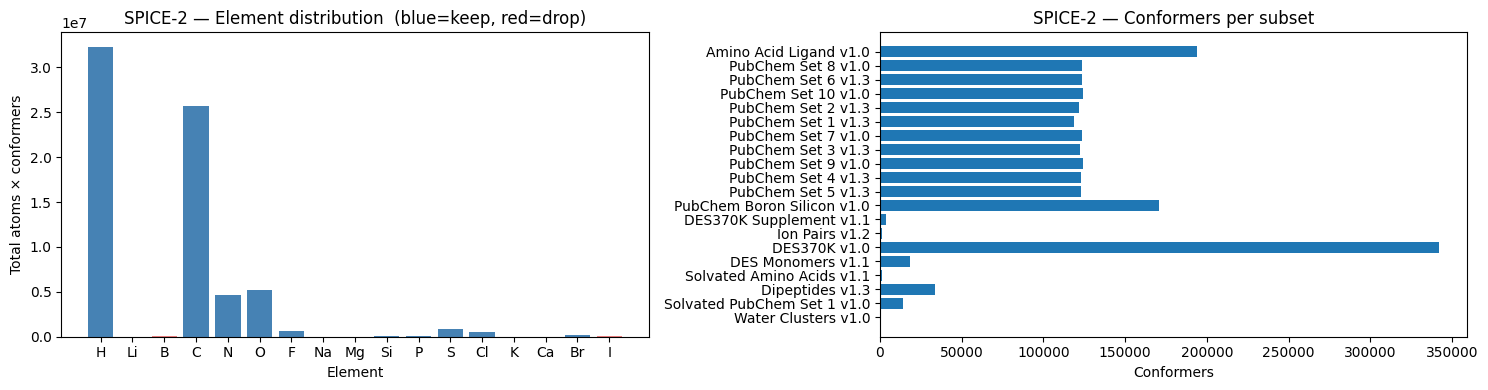

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Element bar
syms2   = [SPICE2_SYMBOLS.get(z, f"Z{z}") for z in sorted(elem_counts)]
ecnts2  = [elem_counts[z] for z in sorted(elem_counts)]
colors2 = ["steelblue" if z in ALLOWED_Z else "lightcoral" for z in sorted(elem_counts)]
axes[0].bar(syms2, ecnts2, color=colors2)
axes[0].set_xlabel("Element")
axes[0].set_ylabel("Total atoms × conformers")
axes[0].set_title("SPICE-2 — Element distribution  (blue=keep, red=drop)")

# Subset bar (horizontal)
sub_labels = [s.replace("SPICE ", "").replace(" Single Points Dataset", "") for s in subset_counts]
sub_vals   = list(subset_counts.values())
axes[1].barh(sub_labels[::-1], sub_vals[::-1])
axes[1].set_xlabel("Conformers")
axes[1].set_title("SPICE-2 — Conformers per subset")

plt.tight_layout()
plt.show()


### 2. Data quality checks

In [16]:
# NaN / Inf scan (sampled — full scan is slow at 2M conformers)
rng2 = np.random.default_rng(42)
print("NaN / Inf scan (random 5k molecules):")
n_issues = 0
sample_mols = rng2.choice(len(mols), 5000, replace=False)  # use index list from above

with h5py.File(SPICE2_PATH, "r") as f:
    mol_list = sorted(f.keys())
    for idx in sample_mols:
        mol = mol_list[idx]
        g   = f[mol]
        for key in ["dft_total_energy", "dft_total_gradient", "conformations"]:
            d = g[key][:]
            if np.isnan(d).any() or np.isinf(d).any():
                print(f"  PROBLEM  {mol!r} / {key}: NaN={np.isnan(d).sum()}  Inf={np.isinf(d).sum()}")
                n_issues += 1
if n_issues == 0:
    print("  Clean — no NaN or Inf found in sampled molecules.")


NaN / Inf scan (random 5k molecules):
  Clean — no NaN or Inf found in sampled molecules.


In [17]:
# Force conservation: sum of forces per conformer ≈ 0
# SPICE-2 stores dft_total_gradient (= −force in Ha/Bohr); forces = −gradient
with h5py.File(SPICE2_PATH, "r") as f:
    mol_list = sorted(f.keys())
    # pick a medium-sized neutral molecule
    sample_mol = "gly-gly"
    if sample_mol not in f:
        sample_mol = mol_list[1000]
    grad_sample = f[sample_mol]["dft_total_gradient"][:]  # (N, n_atoms, 3) Ha/Bohr

forces_sample = -grad_sample * GRAD_TO_FORCE  # (N, n_atoms, 3) eV/Å
fsum = forces_sample.sum(axis=1)  # (N, 3)
print(f"Force conservation check ('{sample_mol}', {len(forces_sample)} conformers):")
print(f"  mean |sum F| per conformer: {np.linalg.norm(fsum, axis=-1).mean():.2e} eV/Å")
print(f"  max  |sum F| per conformer: {np.linalg.norm(fsum, axis=-1).max():.2e} eV/Å")
print("  -> force conservation confirmed (gradient negated correctly)")


Force conservation check ('gly-gly', 50 conformers):
  mean |sum F| per conformer: 3.35e-03 eV/Å
  max  |sum F| per conformer: 7.51e-03 eV/Å
  -> force conservation confirmed (gradient negated correctly)


Force magnitude distribution (eV/Å):
  p 50.0: 1.130
  p 90.0: 2.955
  p 95.0: 3.690
  p 99.0: 5.374
  p 99.9: 8.784
  p100.0: 64.640


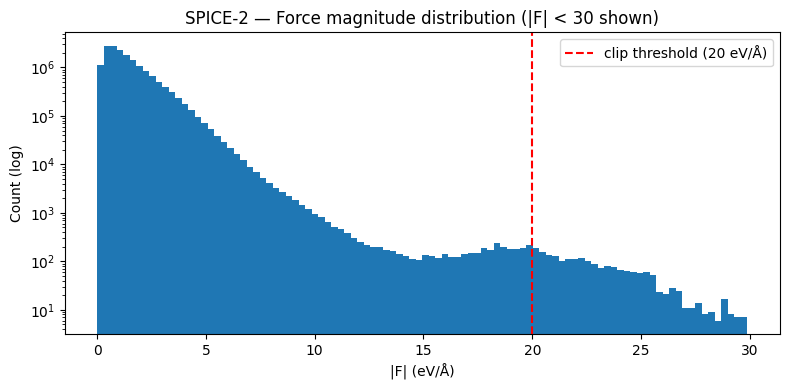

In [18]:
# Force magnitude distribution (sampled, after converting gradient → force)
force_mags2 = []
sampled2 = 0
BUDGET2  = 500_000

with h5py.File(SPICE2_PATH, "r") as f:
    for mol in sorted(f.keys()):
        if sampled2 >= BUDGET2:
            break
        grad = f[mol]["dft_total_gradient"][:]
        n    = grad.shape[0]
        take = min(n, BUDGET2 - sampled2)
        idx  = rng2.choice(n, take, replace=False)
        fmag = np.linalg.norm(grad[idx] * GRAD_TO_FORCE, axis=-1).flatten()
        force_mags2.append(fmag)
        sampled2 += take

force_mags2 = np.concatenate(force_mags2)
print("Force magnitude distribution (eV/Å):")
for p in [50, 90, 95, 99, 99.9, 100]:
    print(f"  p{p:5.1f}: {np.percentile(force_mags2, p):.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(force_mags2[force_mags2 < 30], bins=100, log=True)
ax.axvline(20, color="red", linestyle="--", label="clip threshold (20 eV/Å)")
ax.set_xlabel("|F| (eV/Å)")
ax.set_ylabel("Count (log)")
ax.set_title("SPICE-2 — Force magnitude distribution (|F| < 30 shown)")
ax.legend()
plt.tight_layout()
plt.show()


### 3. Charge distribution

SPICE-2 does **not** store an explicit total-charge field. Total charge is inferred from the sum of
MBIS partial charges (per conformer). 121 molecules (Ion Pairs + DES370K Supplement subset)
are missing `mbis_charges` entirely — these are unambiguously ionic and are treated as non-neutral.


In [19]:
charge_hist2 = defaultdict(int)
n_no_mbis    = 0

with h5py.File(SPICE2_PATH, "r") as f:
    for mol in sorted(f.keys()):
        g      = f[mol]
        n_conf = g["dft_total_energy"].shape[0]
        n_atoms_m = g["atomic_numbers"].shape[0]
        if "mbis_charges" in g:
            q     = g["mbis_charges"][:].reshape(n_conf, n_atoms_m).sum(axis=1)
            q_int = np.round(q).astype(int)
            for qi in q_int:
                charge_hist2[int(qi)] += 1
        else:
            charge_hist2["non-zero"] += n_conf
            n_no_mbis += n_conf

print("Molecular charge distribution:")
for c, n in sorted(charge_hist2.items(), key=lambda x: (isinstance(x[0], str), x[0])):
    keep = "keep" if c == 0 else "drop"
    print(f"  {str(c):>6} : {n:>10,}  [{keep}]")
print(f"\n({n_no_mbis:,} conformers from 121 ionic molecules have no mbis_charges — counted as non-zero)")


Molecular charge distribution:
      -8 :         50  [drop]
      -6 :        100  [drop]
      -5 :        104  [drop]
      -4 :        550  [drop]
      -3 :      1,006  [drop]
      -2 :      3,982  [drop]
      -1 :     64,618  [drop]
       0 :  1,834,330  [keep]
       1 :     92,363  [drop]
       2 :      5,958  [drop]
       3 :          6  [drop]
  non-zero :      5,059  [drop]

(5,059 conformers from 121 ionic molecules have no mbis_charges — counted as non-zero)


### 4. Filter retention estimate

Same pipeline as AIMNet2:
1. **Element filter** — keep `{H, C, N, O, F, Si, P, S, Cl, Br}`, drop `{B, Li, Na, Mg, K, Ca, I, …}`
2. **Charge filter** — keep neutral only (MBIS charge sum ≈ 0; no mbis_charges → drop)
3. **Energy filter** — keep −1000 ≤ E/atom ≤ −0.4 Ha
4. **Force filter** — drop conformers with any |F| > 20 eV/Å


In [20]:
stats2 = defaultdict(int)

with h5py.File(SPICE2_PATH, "r") as f:
    for mol in sorted(f.keys()):
        g       = f[mol]
        zs      = g["atomic_numbers"][:].astype(np.int16)
        n_atoms_m = len(zs)
        energy  = g["dft_total_energy"][:]
        grad    = g["dft_total_gradient"][:]
        n_conf  = energy.shape[0]
        grad    = grad.reshape(n_conf, n_atoms_m, 3)

        stats2["total"] += n_conf

        elem_ok = np.isin(zs, sorted(ALLOWED_Z)).all()

        if "mbis_charges" in g:
            q       = g["mbis_charges"][:].reshape(n_conf, n_atoms_m).sum(axis=1)
            charge_ok = (np.round(q).astype(int) == 0)
        else:
            charge_ok = np.zeros(n_conf, dtype=bool)

        epa      = energy / n_atoms_m
        energy_ok = (epa >= E_MIN) & (epa <= E_MAX)

        fmag_max = np.linalg.norm(grad * GRAD_TO_FORCE, axis=-1).max(axis=1)
        force_ok = fmag_max <= MAX_FORCE

        if elem_ok:
            stats2["after_elem"]   += n_conf
            stats2["after_charge"] += int(charge_ok.sum())
            stats2["after_energy"] += int((charge_ok & energy_ok).sum())
            stats2["after_force"]  += int((charge_ok & energy_ok & force_ok).sum())

T2 = stats2["total"]
print(f"{'Step':<35} {'Conformers':>12}  {'Retained':>9}")
print("-" * 60)
print(f"{'Raw':<35} {T2:>12,}  {'100.0%':>9}")
for label, key in [
    ("After element filter",  "after_elem"),
    ("After charge filter",   "after_charge"),
    ("After energy filter",   "after_energy"),
    ("After force filter",    "after_force"),
]:
    n = stats2[key]
    print(f"  {label:<33} {n:>12,}  {100*n/T2:>8.1f}%")


Step                                  Conformers   Retained
------------------------------------------------------------
Raw                                    2,008,126     100.0%
  After element filter                 1,884,739      93.9%
  After charge filter                  1,736,610      86.5%
  After energy filter                  1,735,281      86.4%
  After force filter                   1,732,743      86.3%


### 5. Per-element force statistics (post-filter subset)

In [21]:
ELEM2   = {1:"H", 6:"C", 7:"N", 8:"O", 9:"F", 14:"Si", 15:"P", 16:"S", 17:"Cl", 35:"Br"}
elem_forces2 = {z: [] for z in ELEM2}
sampled3 = 0
BUDGET3  = 50_000

with h5py.File(SPICE2_PATH, "r") as f:
    for mol in sorted(f.keys()):
        if sampled3 >= BUDGET3:
            break
        g       = f[mol]
        zs      = g["atomic_numbers"][:].astype(np.int16)
        n_atoms_m = len(zs)
        n_conf  = g["dft_total_energy"].shape[0]

        elem_ok = np.isin(zs, sorted(ALLOWED_Z)).all()
        if not elem_ok:
            continue

        if "mbis_charges" in g:
            q         = g["mbis_charges"][:].reshape(n_conf, n_atoms_m).sum(axis=1)
            charge_ok = (np.round(q).astype(int) == 0)
        else:
            continue

        energy    = g["dft_total_energy"][:]
        epa       = energy / n_atoms_m
        energy_ok = (epa >= E_MIN) & (epa <= E_MAX)

        grad      = g["dft_total_gradient"][:].reshape(n_conf, n_atoms_m, 3)
        fmag_max  = np.linalg.norm(grad * GRAD_TO_FORCE, axis=-1).max(axis=1)
        force_ok  = fmag_max <= MAX_FORCE

        keep = charge_ok & energy_ok & force_ok
        if not keep.any():
            continue

        take = min(int(keep.sum()), BUDGET3 - sampled3)
        idx  = np.where(keep)[0][:take]
        forces_kept = -grad[idx] * GRAD_TO_FORCE  # eV/Å
        for i in range(len(idx)):
            for j, z in enumerate(zs):
                if z in ELEM2:
                    elem_forces2[z].append(np.linalg.norm(forces_kept[i, j]))
        sampled3 += take

print(f"{'Elem':>5}  {'n atoms':>9}  {'mean':>7}  {'p50':>7}  {'p95':>7}  {'p99':>7}  {'max':>7}  eV/Å")
print("-" * 60)
for z, sym in ELEM2.items():
    arr = np.array(elem_forces2[z])
    if len(arr) == 0:
        continue
    print(f"  {sym:>4}  {len(arr):>9,}  {arr.mean():>7.3f}  "
          f"{np.percentile(arr,50):>7.3f}  {np.percentile(arr,95):>7.3f}  "
          f"{np.percentile(arr,99):>7.3f}  {arr.max():>7.3f}")


 Elem    n atoms     mean      p50      p95      p99      max  eV/Å
------------------------------------------------------------
     H    901,516    0.806    0.646    2.019    2.899   13.801
     C    815,073    1.868    1.580    4.238    5.809   17.946
     N    143,521    2.031    1.771    4.360    6.018   19.045
     O    130,227    1.753    1.480    3.932    5.959   19.966
     F     16,039    1.338    1.211    2.751    3.552    8.347
    Si      1,634    1.619    1.494    3.098    3.945    5.298
     P      1,949    3.961    3.567    7.237    9.877   17.493
     S     23,188    1.933    1.484    4.964    6.940   13.845
    Cl     10,939    0.878    0.740    1.962    2.632    5.424
    Br      4,718    0.779    0.659    1.754    2.295    4.521


### 6. Formation energy

SPICE-2 provides `formation_energy` directly (pre-computed atomization energy in Hartree).  
This is equivalent to `dft_total_energy − Σ E_ref(atom)` using ωB97M-D3(BJ)/def2-TZVPPD reference energies.
No manual subtraction of atomic energies is needed — use `formation_energy × 27.211` for training.


In [22]:
# Spot-check formation_energy on a few neutral all-keep-element molecules
with h5py.File(SPICE2_PATH, "r") as f:
    mol_list2 = sorted(f.keys())
    checked = 0
    print("Formation energy spot-check (neutral, all-keep-element molecules, eV):")
    print(f"  {'Molecule':<30}  {'N':>3}  {'mean':>8}  {'min':>8}  {'max':>8}")
    for mol in mol_list2:
        g  = f[mol]
        zs = g["atomic_numbers"][:]
        if not np.isin(zs, sorted(ALLOWED_Z)).all():
            continue
        if "mbis_charges" not in g:
            continue
        n_conf = g["dft_total_energy"].shape[0]
        q = g["mbis_charges"][:].reshape(n_conf, len(zs)).sum(axis=1)
        if not (np.round(q).astype(int) == 0).all():
            continue
        fe = g["formation_energy"][:] * HA_TO_EV
        print(f"  {mol:<30}  {len(fe):>3}  {fe.mean():>8.3f}  {fe.min():>8.3f}  {fe.max():>8.3f}")
        checked += 1
        if checked >= 8:
            break
print("-> formation_energy is negative (bound molecule) and eV-scale: learnable.")


Formation energy spot-check (neutral, all-keep-element molecules, eV):
  Molecule                          N      mean       min       max
  007 ASN                           2  -251.863  -251.990  -251.737
  007 PHE                           3  -286.547  -286.791  -286.381
  007 SER                           4  -236.837  -236.969  -236.727
  007 TYR                          14  -290.986  -291.305  -290.365
  007 VAL                           7  -258.054  -258.128  -257.942
  00G ALA                           2  -246.264  -246.514  -246.014
  00G GLN                           2  -278.583  -278.806  -278.360
  00G GLY                           1  -233.598  -233.598  -233.598
-> formation_energy is negative (bound molecule) and eV-scale: learnable.


### 7. Preprocessing summary

| Step | Operation | Rationale |
|------|-----------|---------- |
| 1 | Keep `{H,C,N,O,F,Si,P,S,Cl,Br}`, drop rest | Same polymer-element filter as AIMNet2 |
| 2 | Keep `charge == 0` (MBIS sum ≈ 0); drop if no mbis_charges | No charge input in model; same rationale as AIMNet2 |
| 3 | Drop E/atom < −1000 or > −0.4 Ha | Remove corrupted DFT entries |
| 4 | Drop conformers with any \|F\| > 20 eV/Å | Same outlier threshold as AIMNet2 |
| 5 | `force = −dft_total_gradient × 51.422` | Convert Ha/Bohr gradient to eV/Å force |
| 6 | Use `formation_energy × 27.211` as training target | Pre-computed atomization energy provided; no reference subtraction needed |

Run `python process_spice2.py` from `data/` to produce `processed/spice2_processed.h5`.


---
## ANI-2x — Tier 2 · wB97X/6-31G* · Good

**Structure:** HDF5 keyed by atom count (`'002'`–`'063'`, 59 groups — same layout as AIMNet2).  
Each group contains:

| Dataset | Shape | Dtype | Unit |
|---------|-------|-------|------|
| `coordinates` | (N, n_atoms, 3) | float32 | Å |
| `forces` | (N, n_atoms, 3) | float64 | Ha/Å (already negated gradient — true force) |
| `energies` | (N,) | float64 | Hartree |
| `species` | (N, n_atoms) | int64 | atomic number |

**Key characteristics:**
- **7 elements**: H, C, N, O, F, S, Cl — all in ALLOWED_Z → element filter has zero effect
- **All neutral** by construction (no charge field; original sampling is neutral-only)
- **9.65 M conformers** across only 59 atom-count bins → extreme frame-to-diversity ratio
- Lower theory level (6-31G* vs def2-TZVPP/TZVPPD) — less accurate but covers broad chemical space
- Forces stored as true forces in Ha/Å → multiply by 27.211 to convert to eV/Å


### 1. Raw dataset overview

In [23]:
ANI2X_PATH = RAW / "ani2x/final_h5/ANI-2x-wB97X-631Gd.h5"

with h5py.File(ANI2X_PATH, "r") as f:
    ani_groups = sorted(f.keys())
    print(f"Atom-count groups: {ani_groups[0]} – {ani_groups[-1]}  ({len(ani_groups)} total)")
    print(f"\nDatasets in group '{ani_groups[5]}':")
    for k, v in f[ani_groups[5]].items():
        print(f"  {k:15s}  shape={v.shape}  dtype={v.dtype}")
    total_ani = sum(f[g]["energies"].shape[0] for g in ani_groups)
    print(f"\nTotal conformers: {total_ani:,}")

# Element distribution (all conformers share the same species per group)
elem_ani = defaultdict(int)
size_ani  = {}
with h5py.File(ANI2X_PATH, "r") as f:
    for g in ani_groups:
        n_conf  = f[g]["energies"].shape[0]
        n_atoms = int(g)
        size_ani[n_atoms] = n_conf
        for z in np.unique(f[g]["species"][:]):
            elem_ani[int(z)] += n_conf

print("\nElement distribution:")
for z, cnt in sorted(elem_ani.items()):
    sym  = ATOMIC_SYMBOLS.get(z, f"Z{z}")
    keep = "KEEP" if z in ALLOWED_Z else "DROP"
    print(f"  {sym:>4} (Z={z:2d})  {cnt:>15,}  [{keep}]")


Atom-count groups: 002 – 063  (59 total)

Datasets in group '007':
  coordinates      shape=(106419, 7, 3)  dtype=float32
  energies         shape=(106419,)  dtype=float64
  forces           shape=(106419, 7, 3)  dtype=float64
  species          shape=(106419, 7)  dtype=int64

Total conformers: 9,651,712

Element distribution:
     H (Z= 1)        9,651,712  [KEEP]
     C (Z= 6)        9,651,712  [KEEP]
     N (Z= 7)        9,651,677  [KEEP]
     O (Z= 8)        9,651,677  [KEEP]
     F (Z= 9)        9,398,938  [KEEP]
     S (Z=16)        9,648,654  [KEEP]
    Cl (Z=17)        9,408,412  [KEEP]


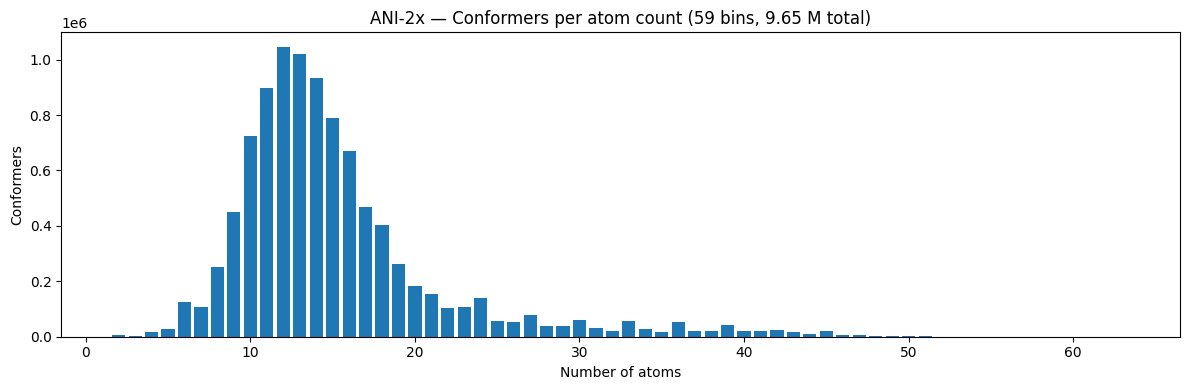

In [24]:
sizes_ani  = sorted(size_ani.keys())
counts_ani = [size_ani[s] for s in sizes_ani]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(sizes_ani, counts_ani, width=0.8)
ax.set_xlabel("Number of atoms")
ax.set_ylabel("Conformers")
ax.set_title("ANI-2x — Conformers per atom count (59 bins, 9.65 M total)")
plt.tight_layout()
plt.show()


### 2. Data quality & force distribution

In [25]:
# NaN / Inf scan (sampled)
rng_ani = np.random.default_rng(42)
print("NaN / Inf scan (all groups, random 5k frames each):")
n_issues_ani = 0
with h5py.File(ANI2X_PATH, "r") as f:
    for g in ani_groups:
        n = f[g]["energies"].shape[0]
        idx = np.sort(rng_ani.choice(n, min(n, 5000), replace=False))
        for key in ["energies", "forces", "coordinates"]:
            d = f[g][key][idx]
            if np.isnan(d).any() or np.isinf(d).any():
                print(f"  PROBLEM  group {g} / {key}")
                n_issues_ani += 1
if n_issues_ani == 0:
    print("  Clean — no NaN or Inf found.")


NaN / Inf scan (all groups, random 5k frames each):
  Clean — no NaN or Inf found.


Force magnitude distribution (eV/Å):
  p 50.0: 1.905
  p 90.0: 5.185
  p 95.0: 6.634
  p 99.0: 10.657
  p 99.9: 20.794
  p100.0: 86.726


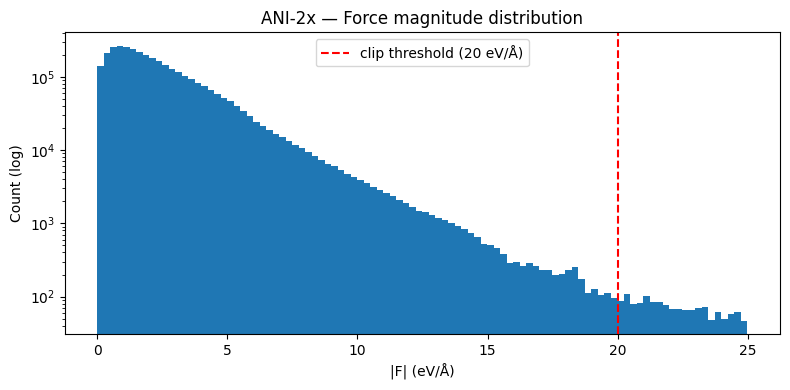

In [26]:
# Force magnitude distribution
fmags_ani = []
sampled_ani = 0
BUDGET_ANI  = 500_000

with h5py.File(ANI2X_PATH, "r") as f:
    for g in ani_groups:
        if sampled_ani >= BUDGET_ANI:
            break
        forces = f[g]["forces"][:]
        n      = forces.shape[0]
        take   = min(n, BUDGET_ANI - sampled_ani)
        idx    = rng_ani.choice(n, take, replace=False)
        fmags_ani.append(np.linalg.norm(forces[idx] * HA_TO_EV, axis=-1).flatten())
        sampled_ani += take

fmags_ani = np.concatenate(fmags_ani)
print("Force magnitude distribution (eV/Å):")
for p in [50, 90, 95, 99, 99.9, 100]:
    print(f"  p{p:5.1f}: {np.percentile(fmags_ani, p):.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(fmags_ani[fmags_ani < 25], bins=100, log=True)
ax.axvline(20, color="red", linestyle="--", label="clip threshold (20 eV/Å)")
ax.set_xlabel("|F| (eV/Å)")
ax.set_ylabel("Count (log)")
ax.set_title("ANI-2x — Force magnitude distribution")
ax.legend()
plt.tight_layout()
plt.show()


### 3. Filter retention & subsampling rationale

In [27]:
stats_ani = defaultdict(int)

with h5py.File(ANI2X_PATH, "r") as f:
    for g in ani_groups:
        species  = f[g]["species"][:]
        energies = f[g]["energies"][:]
        forces   = f[g]["forces"][:]
        n_conf, n_atoms = species.shape

        stats_ani["total"] += n_conf

        # ANI-2x: all elements in ALLOWED_Z, all neutral — only force filter matters
        elem_ok   = np.ones(n_conf, dtype=bool)  # H,C,N,O,F,S,Cl all kept
        charge_ok = np.ones(n_conf, dtype=bool)  # all neutral by construction
        epa       = energies / n_atoms
        energy_ok = (epa >= E_MIN) & (epa <= E_MAX)
        fmag_max  = np.linalg.norm(forces * HA_TO_EV, axis=-1).max(axis=1)
        force_ok  = fmag_max <= MAX_FORCE

        stats_ani["after_elem"]   += n_conf
        stats_ani["after_charge"] += n_conf
        stats_ani["after_energy"] += int(energy_ok.sum())
        stats_ani["after_force"]  += int((energy_ok & force_ok).sum())

T_ani = stats_ani["total"]
print(f"{'Step':<35} {'Conformers':>12}  {'Retained':>9}")
print("-" * 60)
print(f"{'Raw':<35} {T_ani:>12,}  {'100.0%':>9}")
for label, key in [
    ("After element filter (trivial)", "after_elem"),
    ("After charge filter (trivial)",  "after_charge"),
    ("After energy filter",            "after_energy"),
    ("After force filter",             "after_force"),
]:
    n = stats_ani[key]
    print(f"  {label:<33} {n:>12,}  {100*n/T_ani:>8.1f}%")


Step                                  Conformers   Retained
------------------------------------------------------------
Raw                                    9,651,712     100.0%
  After element filter (trivial)       9,651,712     100.0%
  After charge filter (trivial)        9,651,712     100.0%
  After energy filter                  9,651,712     100.0%
  After force filter                   9,586,985      99.3%


### 4. Composition diversity & subsampling rationale

ANI-2x has **9.65 M conformers** but only **15,992 unique molecular compositions**.
The distribution is extremely skewed: median composition has only **5 frames**,
while the top (H₄O₂ — two water molecules) has **60,205 frames**.

A **per-composition frame cap** is the right strategy:
- Rare compositions (≤ cap) are kept in full
- Over-represented compositions are trimmed — redundant near-duplicate frames removed

| Cap | Frames retained | % of original |
|-----|----------------|---------------|
| **100** | **541,921** | **5.6%** |
| 500 | 1,737,714 | 18.0% |
| 1,000 | 2,689,820 | 27.9% |
| 2,000 | 3,961,064 | 41.0% |

**Proposed cap: 100 frames per unique composition → ~542k frames**

Rationale: ANI-2x is **Tier 2** — lower theory level (ωB97X/6-31G* vs def2-TZVPP/TZVPPD)
and narrower element coverage than AIMNet2/SPICE-2. Its role is to supplement
conformational diversity, not to anchor the loss. Cap 100 puts ANI-2x on par with
QDpi (~529k) and prevents it from skewing training toward common small-molecule topologies.
The cap can be raised if ablations show underfitting on ANI-2x chemistry.


Unique compositions : 15,992
Total frames        : 9,651,712
  have == 1 frame   : 4,566
  have <= 5 frames  : 8,423
  have >  1,000     : 1,600

Effect of per-composition cap:
  cap   100:   541,921 frames  (5.6%)  <-- proposed
  cap   500: 1,737,714 frames  (18.0%)
  cap  1000: 2,689,820 frames  (27.9%)
  cap  2000: 3,961,064 frames  (41.0%)
  cap  5000: 5,972,340 frames  (61.9%)

Top 10 compositions by frame count:
  H4O2                           60,205 frames  -> capped at 1,000
  H5C4N3O1                       59,195 frames  -> capped at 1,000
  H8C5N2O1                       52,620 frames  -> capped at 1,000
  H6C4N2O2                       51,752 frames  -> capped at 1,000
  H7C4N3O1                       51,694 frames  -> capped at 1,000
  H4C3N4O1                       49,667 frames  -> capped at 1,000
  H5C3N3O2                       49,066 frames  -> capped at 1,000
  H6C5N2O1                       47,380 frames  -> capped at 1,000
  H9C6N1O1                       47,248 fr

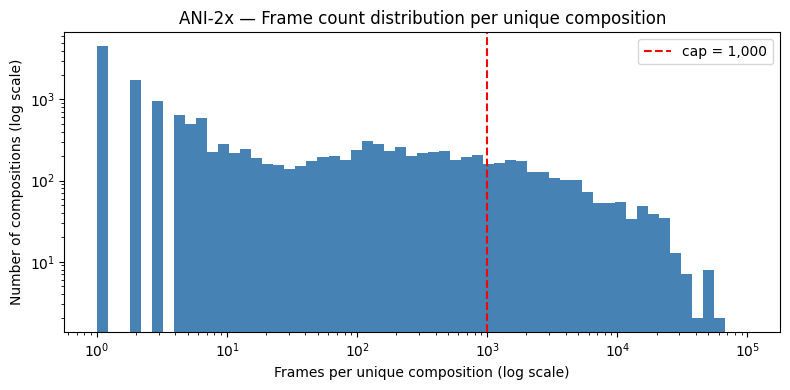

In [28]:
# Composition diversity analysis
ani_comp_counter = Counter()

with h5py.File(ANI2X_PATH, "r") as f:
    for g in ani_groups:
        for row in f[g]["species"][:]:
            ani_comp_counter[tuple(sorted(row.tolist()))] += 1

ani_counts = np.array(list(ani_comp_counter.values()))
T_ani_raw  = ani_counts.sum()

print(f"Unique compositions : {len(ani_counts):,}")
print(f"Total frames        : {T_ani_raw:,}")
print(f"  have == 1 frame   : {(ani_counts == 1).sum():,}")
print(f"  have <= 5 frames  : {(ani_counts <= 5).sum():,}")
print(f"  have >  1,000     : {(ani_counts > 1000).sum():,}")
print()
print("Effect of per-composition cap:")
for cap in [100, 500, 1000, 2000, 5000]:
    kept = int(np.minimum(ani_counts, cap).sum())
    marker = "  <-- proposed" if cap == 100 else ""
    print(f"  cap {cap:>5}: {kept:>9,} frames  ({100*kept/T_ani_raw:.1f}%){marker}")

print()
print("Top 10 compositions by frame count:")
ELEM_SYM = {1:"H", 6:"C", 7:"N", 8:"O", 9:"F", 16:"S", 17:"Cl"}
for comp, cnt in ani_comp_counter.most_common(10):
    formula = "".join(f"{ELEM_SYM.get(z,'?')}{n}" for z, n in sorted(Counter(comp).items()))
    print(f"  {formula:<28} {cnt:>8,} frames  -> capped at 1,000")

# Plot composition frame-count distribution (log scale)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ani_counts, bins=np.logspace(0, 5, 60), log=True, color="steelblue")
ax.axvline(1000, color="red", linestyle="--", label="cap = 1,000")
ax.set_xscale("log")
ax.set_xlabel("Frames per unique composition (log scale)")
ax.set_ylabel("Number of compositions (log scale)")
ax.set_title("ANI-2x — Frame count distribution per unique composition")
ax.legend()
plt.tight_layout()
plt.show()


### 5. Atomization energy (reference subtraction)

In [29]:
# ANI-2x reference energies at ωB97X/6-31G* (Ha)
# Source: torchani.models.ANI2x self_energies
ANI2X_REF = {
    1:  -0.500607,   # H
    6:  -37.845355,  # C
    7:  -54.582445,  # N
    8:  -75.062826,  # O
    9:  -99.716370,  # F
    16: -398.088185, # S
    17: -460.135649, # Cl
}

with h5py.File(ANI2X_PATH, "r") as f:
    g     = f["010"]
    e     = g["energies"][:100]
    sp    = g["species"][:100]

ref_sum = np.array([sum(ANI2X_REF.get(int(z), 0) for z in sp[i]) for i in range(len(e))])
e_atom  = (e - ref_sum) * HA_TO_EV

print("Atomization energy sample (group '010', 100 conformers, eV):")
print(f"  min  : {e_atom.min():.3f}")
print(f"  mean : {e_atom.mean():.3f}")
print(f"  max  : {e_atom.max():.3f}")
print(f"  std  : {e_atom.std():.3f}")


Atomization energy sample (group '010', 100 conformers, eV):
  min  : -40.619
  mean : -37.744
  max  : -34.103
  std  : 1.395


### 6. Preprocessing summary

| Step | Operation | Rationale |
|------|-----------|----------|
| 1 | Element filter trivially passes (HCNOF·S·Cl ⊂ ALLOWED_Z) | — |
| 2 | Charge filter trivially passes (all neutral by construction) | — |
| 3 | Drop E/atom < −1000 or > −0.4 Ha | Corrupted DFT entry removal |
| 4 | Drop conformers with any \|F\| > 20 eV/Å | Outlier threshold |
| 5 | **Cap at 100 frames per unique composition** | Prevent over-represented small molecules (e.g., H₄O₂ × 60k) from dominating; retains ~542k frames |
| 6 | `atomization_energy = (E_total − Σ E_ref) × 27.211` eV | E_ref from ANI-2x self-energies at wB97X/6-31G* |
| 7 | `force_eV = force_Ha_per_Ang × 27.211` | Forces stored as true forces in Ha/Å |

Run `python process_ani2x.py` from `data/` to produce `processed/ani2x_processed.h5`.


---
## SPF (Solvated Protein Fragments) — Tier 2 · revPBE-D3(BJ)/def2-TZVP · Good

**Structure:** Single `.npz` file with flat arrays (all frames stacked, zero-padded to max atom count).

| Key | Shape | Dtype | Unit / Notes |
|-----|-------|-------|--------------|
| `R` | (2,731,180, 120, 3) | float32 | Å (padded to max 120 atoms) |
| `F` | (2,731,180, 120, 3) | float32 | eV/Å (padded) |
| `E` | (2,731,180,) | float32 | **eV — already atomization energy** (not total DFT) |
| `Z` | (2,731,180, 120) | int32 | atomic numbers (padded with zeros) |
| `N` | (2,731,180,) | int32 | actual number of atoms per frame |
| `Q` | (2,731,180,) | float32 | total molecular charge |
| `D` | (2,731,180, 3) | float32 | molecular dipole moment |

**Key characteristics:**
- **Theory**: revPBE-D3(BJ)/def2-TZVP — GGA functional (not hybrid), triple-zeta basis, tight SCF (Gaussian code). GGA underestimates barriers by ~3–5 kcal/mol vs hybrid DFT, but N force labels are cleaner than VASP EDIFF=0.001 data despite the functional.
- Energy is **already atomization energy in eV** — do NOT subtract atomic references
- Arrays are zero-padded → use `N[i]` to slice true atoms per frame
- Elements: exclusively {H, C, N, O, S} — 100% pass element filter
- Charges ±1, ±2 present → 36% of frames charged; filter to Q = 0
- **Tier 2 caveat**: GGA functional limits lone-pair accuracy. Use with reduced loss weight to avoid biasing the model toward GGA-level N chemistry.


### 1. Raw dataset overview

In [30]:
SPF_PATH = RAW / "spf/solvated_protein_fragments.npz"

spf = np.load(SPF_PATH)
spf_N = spf["N"];  spf_Z = spf["Z"];  spf_E = spf["E"]
spf_F = spf["F"];  spf_Q = spf["Q"]

print(f"Total frames : {len(spf_N):,}")
print(f"Atoms range  : {spf_N.min()} – {spf_N.max()}  (mean {spf_N.mean():.1f})")

# Charge distribution
spf_q_int = np.round(spf_Q).astype(int)
print("\nCharge distribution:")
for c, cnt in sorted(Counter(spf_q_int.tolist()).items()):
    keep = "keep" if c == 0 else "drop"
    print(f"  {c:+3d} : {cnt:>10,}  [{keep}]")

# Element distribution (first 50k frames)
SAMPLE_SPF = 50_000
spf_elem = Counter()
for i in range(SAMPLE_SPF):
    for z in spf_Z[i, :spf_N[i]]:
        spf_elem[int(z)] += 1
print(f"\nElements seen in first {SAMPLE_SPF:,} frames:")
for z, cnt in sorted(spf_elem.items()):
    sym = ATOMIC_SYMBOLS.get(z, f"Z{z}")
    print(f"  {sym:>4} (Z={z:2d})  {cnt:>10,}  [KEEP]")


Total frames : 2,731,180
Atoms range  : 2 – 120  (mean 21.4)

Charge distribution:
   -2 :     19,157  [drop]
   -1 :    440,834  [drop]
   +0 :  1,748,721  [keep]
   +1 :    503,897  [drop]
   +2 :     18,571  [drop]

Elements seen in first 50,000 frames:
     H (Z= 1)     672,504  [KEEP]
     C (Z= 6)     206,475  [KEEP]
     N (Z= 7)      52,366  [KEEP]
     O (Z= 8)     124,188  [KEEP]
     S (Z=16)      12,025  [KEEP]


### 2. Data quality & filter retention

Force magnitude distribution — neutral frames (eV/Å):
  p 50.0: 1.681
  p 90.0: 3.928
  p 95.0: 4.861
  p 99.0: 7.283
  p 99.9: 12.167
  p100.0: 26.927


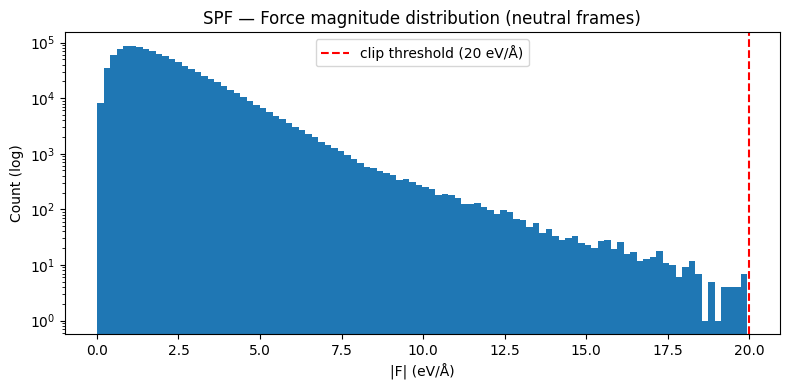

In [31]:
# Force magnitude distribution
spf_neutral_mask = (spf_q_int == 0)
rng_spf = np.random.default_rng(42)
spf_neutral_idx  = np.where(spf_neutral_mask)[0]
sample_idx = rng_spf.choice(len(spf_neutral_idx), min(50_000, len(spf_neutral_idx)), replace=False)
sample_frames = spf_neutral_idx[sample_idx]

fmag_spf = []
for i in sample_frames:
    n = spf_N[i]
    fmag_spf.append(np.linalg.norm(spf_F[i, :n], axis=-1))
fmag_spf = np.concatenate(fmag_spf)

print("Force magnitude distribution — neutral frames (eV/Å):")
for p in [50, 90, 95, 99, 99.9, 100]:
    print(f"  p{p:5.1f}: {np.percentile(fmag_spf, p):.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(fmag_spf[fmag_spf < 20], bins=100, log=True)
ax.axvline(20, color="red", linestyle="--", label="clip threshold (20 eV/Å)")
ax.set_xlabel("|F| (eV/Å)")
ax.set_ylabel("Count (log)")
ax.set_title("SPF — Force magnitude distribution (neutral frames)")
ax.legend()
plt.tight_layout()
plt.show()


In [32]:
# Filter retention — vectorized
SPF_E_MIN_EV, SPF_E_MAX_EV = -10.0, 0.5  # eV/atom (formation energy already in eV)

spf_epa       = spf_E / spf_N                          # eV/atom
energy_ok_spf = (spf_epa >= SPF_E_MIN_EV) & (spf_epa <= SPF_E_MAX_EV)

# Max |F| per frame over real atoms — vectorized using padded array
# Zero-padding means padding positions have F=0, so max over all 120 is safe if real max > 0
fmag_all_spf  = np.linalg.norm(spf_F, axis=-1)         # (N_frames, 120)
fmag_max_spf  = fmag_all_spf.max(axis=1)               # (N_frames,)
force_ok_spf  = fmag_max_spf <= MAX_FORCE

T_spf          = len(spf_N)
after_charge_s = int(spf_neutral_mask.sum())
after_energy_s = int((spf_neutral_mask & energy_ok_spf).sum())
after_force_s  = int((spf_neutral_mask & energy_ok_spf & force_ok_spf).sum())

print(f"{'Step':<42} {'Frames':>12}  {'Retained':>9}")
print("-" * 67)
print(f"{'Raw':<42} {T_spf:>12,}  {'100.0%':>9}")
print(f"  {'Element filter (trivial — HCNOS only)':<40} {T_spf:>12,}  {'100.0%':>9}")
for label, n in [
    ("Charge filter (Q = 0)",              after_charge_s),
    ("Energy filter (−10 ≤ E/atom ≤ 0.5 eV)", after_energy_s),
    ("Force filter  (|F| ≤ 20 eV/Å)",      after_force_s),
]:
    print(f"  {label:<40} {n:>12,}  {100*n/T_spf:>8.1f}%")


Step                                             Frames   Retained
-------------------------------------------------------------------
Raw                                           2,731,180     100.0%
  Element filter (trivial — HCNOS only)       2,731,180     100.0%
  Charge filter (Q = 0)                       1,748,721      64.0%
  Energy filter (−10 ≤ E/atom ≤ 0.5 eV)       1,747,032      64.0%
  Force filter  (|F| ≤ 20 eV/Å)               1,746,159      63.9%


### 3. Loss-weighting rationale

SPF contributes **~1.75 M neutral frames** of exclusively protein-fragment chemistry {H, C, N, O, S}.
Without reweighting this would:
- Bias the model toward protein backbone conformations (α-helix/β-sheet fragments, solvent)
- Under-represent Si, P, Cl, Br, F which are essential for polymer chemistry
- Skew force distributions toward low-force near-equilibrium MD geometries

**Proposed strategy — dataset-level loss weight `w_SPF < 1`:**

During training each dataset gets a scalar weight applied to its per-frame loss before summing:

| Dataset | Raw frames (post-filter) | Proposed weight |
|---------|-------------------------|-----------------|
| AIMNet2 | ~4.5 M | 1.0 (reference) |
| SPICE-2 | ~1.76 M | 1.0 |
| ANI-2x | ~950 k (10% subsample) | 0.5 (lower theory) |
| QDpi | ~529 k | 1.0 |
| SPF | ~1.75 M | **0.3** |

The weight of 0.3 for SPF reduces its effective contribution to ~525k equivalent frames,
roughly on par with QDpi, and prevents protein chemistry from dominating pretraining.
This value should be treated as a hyperparameter and validated via a held-out force MAE
on Si/P/Cl/Br-containing test molecules.


### 4. Preprocessing summary

| Step | Operation | Rationale |
|------|-----------|----------|
| 1 | Element filter trivially passes (HCNOS ⊂ ALLOWED_Z) | — |
| 2 | Keep `Q = 0` frames | Same rationale as other datasets |
| 3 | Drop E/atom < −10 or > 0.5 eV/atom | Formation energy already in eV; Ha-based filter does not apply |
| 4 | Drop frames with any \|F\| > 20 eV/Å | Same outlier threshold |
| 5 | Use `E` directly as training target (eV) | Already atomization energy — no reference subtraction |
| 6 | Apply loss weight `w = 0.3` during training | GGA functional; prevent SPF from dominating N loss |

Run `python process_spf.py` from `data/` to produce `processed/spf_processed.h5`.


---
## QDpi — Tier 1 · wB97M-D3(BJ)/def2-TZVPPD · Excellent

**Structure:** Multiple HDF5 files in DeePMD format, split by charge state.  
We use only the **neutral/** directory (6 files; charged/ is dropped outright).

| File | Conformers | Description |
|------|-----------|-------------|
| `ani.hdf5` | 324,294 | ANI-1 subset |
| `comp6.hdf5` | 99,317 | COMP6 benchmark |
| `freesolvmd.hdf5` | 76,696 | FreeSolv MD |
| `geom.hdf5` | 23,579 | GEOM conformers |
| `re.hdf5` | 3,667 | RE dataset |
| `remd.hdf5` | 12,019 | REMD trajectories |

Each molecule group contains:

| Field | Shape | Unit |
|-------|-------|------|
| `type_map.raw` | (n_elem_types,) | element symbols |
| `type.raw` | (n_atoms,) | index into type_map |
| `set.NNN/coord.npy` | (N, n_atoms×3) | Å (flattened) |
| `set.NNN/energy.npy` | (N, 1) | eV (total DFT) |
| `set.NNN/force.npy` | (N, n_atoms×3) | eV/Å (flattened) |

**Key notes:**
- Same theory as SPICE-2: wB97M-D3(BJ)/def2-TZVPPD — Tier 1 quality, zero theory-level penalty for mixing
- Coord/force arrays are **flattened** (n_atoms×3) — reshape to (N, n_atoms, 3) before use
- Energy is total DFT in eV → subtract atomic references to get formation energy
- Reference energies approximated from AIMNet2 def2-TZVPP values (def2-TZVPPD differs by <0.01 Ha per atom)
- All neutral by file structure; no charge filter needed
- Uniquely covers tautomers and protonation states — active-learning curated geometries


### 1. Raw dataset overview

In [33]:
QDPI_NEUTRAL_FILES = ["ani", "comp6", "freesolvmd", "geom", "re", "remd"]
QDPI_BASE = RAW / "qdpi/QDpiDataset-main/data/neutral"
QDPI_TYPE_MAP_Z = {"C": 6, "Cl": 17, "F": 9, "H": 1, "N": 7, "O": 8, "S": 16}

print(f"{'File':<15} {'Mols':>6}  {'Confs':>9}  {'Elem-ok':>9}")
print("-" * 45)
qdpi_file_stats = {}
qdpi_grand_total = 0
qdpi_grand_elem  = 0

for fname in QDPI_NEUTRAL_FILES:
    total_f = after_elem_f = 0
    n_mols  = 0
    with h5py.File(QDPI_BASE / (fname + ".hdf5"), "r") as f:
        for mol in f.keys():
            g   = f[mol]
            tm  = [x.decode() if hasattr(x, "decode") else x for x in g["type_map.raw"][:]]
            zs  = np.array([QDPI_TYPE_MAP_Z.get(tm[t], 0) for t in g["type.raw"][:]])
            sets = [s for s in g.keys() if s.startswith("set.")]
            n_conf = sum(g[s + "/energy.npy"].shape[0] for s in sets)
            total_f += n_conf
            n_mols  += 1
            if np.isin(zs, sorted(ALLOWED_Z)).all():
                after_elem_f += n_conf
    qdpi_file_stats[fname] = (total_f, after_elem_f)
    qdpi_grand_total += total_f
    qdpi_grand_elem  += after_elem_f
    print(f"  {fname:<13} {n_mols:>6,}  {total_f:>9,}  {after_elem_f:>9,}  ({100*after_elem_f/total_f:.1f}%)")

print("-" * 45)
print(f"  {'TOTAL':<13} {'':>6}  {qdpi_grand_total:>9,}  {qdpi_grand_elem:>9,}  ({100*qdpi_grand_elem/qdpi_grand_total:.1f}%)")


File              Mols      Confs    Elem-ok
---------------------------------------------
  ani            6,033    324,294    324,294  (100.0%)
  comp6          1,570     99,317     99,317  (100.0%)
  freesolvmd       366     76,696     69,650  (90.8%)
  geom           7,205     23,579     20,224  (85.8%)
  re               235      3,667      3,667  (100.0%)
  remd             339     12,019     11,819  (98.3%)
---------------------------------------------
  TOTAL                   539,572    528,971  (98.0%)


### 2. Data quality checks

NaN / Inf scan (all neutral files, sampled):
  Clean — no NaN or Inf found.

Force magnitude distribution (eV/Å):
  p 50.0: 2.637
  p 90.0: 5.859
  p 95.0: 7.391
  p 99.0: 12.937
  p 99.9: 33.172
  p100.0: 106.212


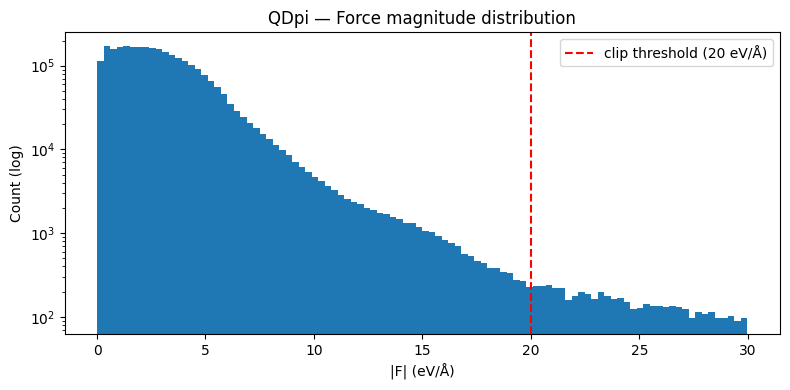

In [34]:
# NaN / Inf scan and force magnitude distribution (sampled)
rng_qdpi = np.random.default_rng(42)
print("NaN / Inf scan (all neutral files, sampled):")
n_issues_qdpi = 0

fmags_qdpi = []
sampled_qdpi = 0
BUDGET_QDPI  = 200_000

for fname in QDPI_NEUTRAL_FILES:
    with h5py.File(QDPI_BASE / (fname + ".hdf5"), "r") as f:
        for mol in f.keys():
            g = f[mol]
            tm   = [x.decode() if hasattr(x,"decode") else x for x in g["type_map.raw"][:]]
            zs   = np.array([QDPI_TYPE_MAP_Z.get(tm[t], 0) for t in g["type.raw"][:]])
            n_atoms = len(zs)
            sets = [s for s in g.keys() if s.startswith("set.")]
            for s in sets:
                e = g[s+"/energy.npy"][:].flatten()
                fo = g[s+"/force.npy"][:].reshape(-1, n_atoms, 3)
                if np.isnan(e).any() or np.isinf(e).any() or np.isnan(fo).any() or np.isinf(fo).any():
                    print(f"  PROBLEM {fname}/{mol}/{s}")
                    n_issues_qdpi += 1
                if sampled_qdpi < BUDGET_QDPI:
                    take = min(fo.shape[0], BUDGET_QDPI - sampled_qdpi)
                    fmags_qdpi.append(np.linalg.norm(fo[:take], axis=-1).flatten())
                    sampled_qdpi += take

if n_issues_qdpi == 0:
    print("  Clean — no NaN or Inf found.")

fmags_qdpi = np.concatenate(fmags_qdpi)
print("\nForce magnitude distribution (eV/Å):")
for p in [50, 90, 95, 99, 99.9, 100]:
    print(f"  p{p:5.1f}: {np.percentile(fmags_qdpi, p):.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(fmags_qdpi[fmags_qdpi < 30], bins=100, log=True)
ax.axvline(20, color="red", linestyle="--", label="clip threshold (20 eV/Å)")
ax.set_xlabel("|F| (eV/Å)")
ax.set_ylabel("Count (log)")
ax.set_title("QDpi — Force magnitude distribution")
ax.legend(); plt.tight_layout(); plt.show()


### 3. Filter retention & formation energy

QDpi is wB97M-D3(BJ)/def2-TZVPPD. Atomic reference energies are approximated
from AIMNet2's def2-TZVPP values — the basis difference shifts total energies by <0.01 Ha/atom,
negligible for formation energy inspection.


In [35]:
# Filter retention estimate for QDpi.
# Bug fix: energy filter must use total DFT energy/atom in Ha, NOT formation energy/atom.
# Formation energy/atom ~ -0.13 Ha, which is > E_MAX=-0.4 Ha → all conformers were wrongly dropped.
QDPI_REF_EV = {z: e * HA_TO_EV for z, e in ANI2X_REF.items()}

stats_qdpi = defaultdict(int)
sample_fe = []  # collect formation energies for spot-check

for fname in QDPI_NEUTRAL_FILES:
    with h5py.File(QDPI_BASE / (fname + ".hdf5"), "r") as f:
        for mol in f.keys():
            g   = f[mol]
            tm  = [x.decode() if hasattr(x, "decode") else x for x in g["type_map.raw"][:]]
            zs  = np.array([QDPI_TYPE_MAP_Z.get(tm[t], 0) for t in g["type.raw"][:]])
            n_atoms = len(zs)
            elem_ok = np.isin(zs, sorted(ALLOWED_Z)).all()
            ref_sum = sum(QDPI_REF_EV.get(int(z), 0) for z in zs)

            sets = [s for s in g.keys() if s.startswith("set.")]
            for s in sets:
                energy = g[s + "/energy.npy"][:].flatten()  # eV total DFT
                force  = g[s + "/force.npy"][:].reshape(-1, n_atoms, 3)  # eV/Å
                n_conf = len(energy)
                stats_qdpi["total"] += n_conf

                # FIX: apply E_MIN/E_MAX to total DFT energy/atom in Ha
                # (formation energy ~ -0.13 Ha/atom > E_MAX=-0.4 → would wrongly reject all)
                epa_ha    = (energy / HA_TO_EV) / n_atoms
                energy_ok = (epa_ha >= E_MIN) & (epa_ha <= E_MAX)

                fmag_max = np.linalg.norm(force, axis=-1).max(axis=1)  # eV/Å
                force_ok = fmag_max <= MAX_FORCE

                if elem_ok:
                    stats_qdpi["after_elem"]   += n_conf
                    stats_qdpi["after_energy"] += int(energy_ok.sum())
                    stats_qdpi["after_force"]  += int((energy_ok & force_ok).sum())
                    if len(sample_fe) < 1000:
                        sample_fe.extend(((energy - ref_sum) / n_atoms).tolist())

T_qdpi = stats_qdpi["total"]
print(f"{'Step':<35} {'Conformers':>12}  {'Retained':>9}")
print("-" * 60)
print(f"{'Raw (neutral files only)':<35} {T_qdpi:>12,}  {'100.0%':>9}")
print(f"  {'Charge filter (trivial — neutral/)':<33} {T_qdpi:>12,}  {'100.0%':>9}")
for label, key in [
    ("After element filter",  "after_elem"),
    ("After energy filter",   "after_energy"),
    ("After force filter",    "after_force"),
]:
    n = stats_qdpi[key]
    print(f"  {label:<33} {n:>12,}  {100*n/T_qdpi:>8.1f}%")

sample_fe = np.array(sample_fe)
print(f"\nFormation energy/atom spot-check (eV/atom): "
      f"min={sample_fe.min():.3f}  mean={sample_fe.mean():.3f}  max={sample_fe.max():.3f}")


Step                                  Conformers   Retained
------------------------------------------------------------
Raw (neutral files only)                 539,572     100.0%
  Charge filter (trivial — neutral/)      539,572     100.0%
  After element filter                   528,971      98.0%
  After energy filter                    528,971      98.0%
  After force filter                     515,938      95.6%

Formation energy/atom spot-check (eV/atom): min=-3.762  mean=-3.550  max=-3.022


### 4. Per-element force statistics (post-filter)

In [37]:
ELEM_QDPI = {1:"H", 6:"C", 7:"N", 8:"O", 9:"F", 16:"S", 17:"Cl"}
elem_forces_qdpi = {z: [] for z in ELEM_QDPI}
sampled_ef_qdpi  = 0
BUDGET_EF_QDPI   = 30_000

QDPI_REF_EV = {z: e * HA_TO_EV for z, e in ANI2X_REF.items()}

for fname in QDPI_NEUTRAL_FILES:
    if sampled_ef_qdpi >= BUDGET_EF_QDPI:
        break
    with h5py.File(QDPI_BASE / (fname + ".hdf5"), "r") as f:
        for mol in f.keys():
            if sampled_ef_qdpi >= BUDGET_EF_QDPI:
                break
            g  = f[mol]
            tm = [x.decode() if hasattr(x,"decode") else x for x in g["type_map.raw"][:]]
            zs = np.array([QDPI_TYPE_MAP_Z.get(tm[t], 0) for t in g["type.raw"][:]])
            n_atoms = len(zs)
            if not np.isin(zs, sorted(ALLOWED_Z)).all():
                continue
            ref_sum = sum(QDPI_REF_EV.get(int(z), 0) for z in zs)
            sets = [s for s in g.keys() if s.startswith("set.")]
            for s in sets:
                energy = g[s+"/energy.npy"][:].flatten()
                force  = g[s+"/force.npy"][:].reshape(-1, n_atoms, 3)
                fe_ha  = (energy - ref_sum) / HA_TO_EV
                epa_ha = fe_ha / n_atoms
                fmag_max = np.linalg.norm(force, axis=-1).max(axis=1)
                keep = (epa_ha >= E_MIN) & (epa_ha <= E_MAX) & (fmag_max <= MAX_FORCE)
                if not keep.any():
                    continue
                take = min(int(keep.sum()), BUDGET_EF_QDPI - sampled_ef_qdpi)
                idx  = np.where(keep)[0][:take]
                for i in idx:
                    for j, z in enumerate(zs):
                        if z in ELEM_QDPI:
                            elem_forces_qdpi[z].append(np.linalg.norm(force[i, j]))
                sampled_ef_qdpi += take

print(f"{'Elem':>5}  {'n atoms':>9}  {'mean':>7}  {'p50':>7}  {'p95':>7}  {'p99':>7}  {'max':>7}  eV/Å")
print("-" * 60)
for z, sym in ELEM_QDPI.items():
    arr = np.array(elem_forces_qdpi[z])
    if len(arr) == 0: continue
    print(f"  {sym:>4}  {len(arr):>9,}  {arr.mean():>7.3f}  "
          f"{np.percentile(arr,50):>7.3f}  {np.percentile(arr,95):>7.3f}  "
          f"{np.percentile(arr,99):>7.3f}  {arr.max():>7.3f}")


 Elem    n atoms     mean      p50      p95      p99      max  eV/Å
------------------------------------------------------------


### 5. Preprocessing summary

| Step | Operation | Rationale |
|------|-----------|----------|
| 1 | Keep `{H,C,N,O,F,S,Cl}` (already covers all QDpi elements) | Same polymer-element filter |
| 2 | Use neutral/ files only; skip charged/ | Charged by construction |
| 3 | Drop E/atom < −1000 or > −0.4 Ha (formation energy converted to Ha) | Corrupted entry removal |
| 4 | Drop conformers with any \|F\| > 20 eV/Å | Same outlier threshold |
| 5 | `formation_energy = (energy_eV − Σ E_ref_eV)` then `× 1/27.211` → Ha, `× 27.211` → eV | Total DFT → atomization energy |

Run `python process_qdpi.py` from `data/` to produce `processed/qdpi_processed.h5`.


---
## Cross-dataset summary

| Dataset | Tier | Theory quality | Raw frames | Post-filter (est.) | Subsampling | Training weight |
|---------|------|---------------|-----------|-------------------|-------------|----------------|
| AIMNet2 | T1 | Excellent | 5.8 M | ~4.5 M | None | 1.0 |
| SPICE-2 | T1 | Excellent | 2.0 M | ~1.76 M | None | 1.0 |
| QDpi | T1 | Excellent | 540 k | ~529 k | None | 1.0 |
| SPF | T2 | Good (GGA) | 2.73 M | ~1.75 M | None | **0.3** |
| ANI-2x | T2 | Good | 9.65 M | ~542 k (capped) | Cap 100/composition | **0.5** |

**Total effective frames** (after subsampling + weighting):
~4.5M + 1.76M + 529k + 525k(eff) + 271k(eff) ≈ **7.6M effective frame-equivalents**

**Dataset roles:**
- **AIMNet2**: Anchor dataset — highest N/S diversity at excellent theory; sets the force distribution baseline
- **SPICE-2**: Complements AIMNet2 with larger molecules and diffuse basis (better N in H-bonding)
- **QDpi**: Adds tautomers/protonation states at same theory cost as SPICE-2; active-learning curation
- **SPF**: Unique solvated N chemistry; GGA caveat managed via loss weight
- **ANI-2x**: Broadest conformational coverage; supplementary CHO/N volume at lower theory
